# Employee Burnout Analysis



## 1. Load Data
Load the train and test CSV files.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

## 2. Data Cleaning

In [ ]:
train.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


In [ ]:
test.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score
0,fffe31003300390039003000,2008-12-10,Female,Service,No,2.0,5.0,7.7
1,fffe31003300310037003800,2008-08-14,Female,Product,Yes,1.0,2.0,5.2
2,fffe33003400380035003900,2008-11-13,Male,Product,Yes,1.0,3.0,5.9
3,fffe3100370039003200,2008-02-07,Female,Service,No,3.0,6.0,4.6
4,fffe32003600390036003700,2008-07-17,Female,Product,No,2.0,5.0,6.4


In [ ]:
train.shape

(22750, 9)

In [ ]:
test.shape

(12250, 8)

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           22750 non-null  object 
 1   Date of Joining       22750 non-null  object 
 2   Gender                22750 non-null  object 
 3   Company Type          22750 non-null  object 
 4   WFH Setup Available   22750 non-null  object 
 5   Designation           22750 non-null  float64
 6   Resource Allocation   21369 non-null  float64
 7   Mental Fatigue Score  20633 non-null  float64
 8   Burn Rate             21626 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.6+ MB


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12250 entries, 0 to 12249
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           12250 non-null  object 
 1   Date of Joining       12250 non-null  object 
 2   Gender                12250 non-null  object 
 3   Company Type          12250 non-null  object 
 4   WFH Setup Available   12250 non-null  object 
 5   Designation           12250 non-null  float64
 6   Resource Allocation   12250 non-null  float64
 7   Mental Fatigue Score  12250 non-null  float64
dtypes: float64(3), object(5)
memory usage: 765.8+ KB


In [ ]:
train.describe()

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
count,22750.000000,21369.000000,20633.000000,21626.000000
mean,2.178725,4.481398,5.728188,0.452005
std,1.135145,2.047211,1.920839,0.198226
min,0.000000,1.000000,0.000000,0.000000
25%,1.000000,3.000000,4.600000,0.310000
50%,2.000000,4.000000,5.900000,0.450000
75%,3.000000,6.000000,7.100000,0.590000
max,5.000000,10.000000,10.000000,1.000000


In [ ]:
test.describe()

,Designation,Resource Allocation,Mental Fatigue Score
count,12250.000000,12250.000000,12250.000000
mean,2.175265,4.458857,5.720571
std,1.132885,2.045602,1.914063
min,0.000000,1.000000,0.000000
25%,1.000000,3.000000,4.500000
50%,2.000000,4.000000,5.900000
75%,3.000000,6.000000,7.100000
max,5.000000,10.000000,10.000000


### Check Missing Values
Display the count of missing values per column, sorted in descending order.

In [ ]:
train.isnull().sum().sort_values(ascending=False)

Mental Fatigue Score    2117
Resource Allocation     1381
Burn Rate               1124
Employee ID                0
Date of Joining            0
Gender                     0
Company Type               0
WFH Setup Available        0
Designation                0
dtype: int64

In [ ]:
test.isnull().sum().sort_values(ascending=False)

Employee ID             0
Date of Joining         0
Gender                  0
Company Type            0
WFH Setup Available     0
Designation             0
Resource Allocation     0
Mental Fatigue Score    0
dtype: int64

## 3. Handle Missing Values
Fill missing values in `Resource Allocation` and `Mental Fatigue Score` with the median, and drop rows where `Burn Rate` (the target column) is missing.

In [ ]:
train["Resource Allocation"] = train["Resource Allocation"].fillna(
    train["Resource Allocation"].median()
)

In [ ]:
test["Resource Allocation"] = test["Resource Allocation"].fillna(
    train["Resource Allocation"].median()
)

In [ ]:
train["Mental Fatigue Score"] = train["Mental Fatigue Score"].fillna(
    train["Mental Fatigue Score"].median()
)

In [ ]:
test["Mental Fatigue Score"] = test["Mental Fatigue Score"].fillna(
    test["Mental Fatigue Score"].median()
)

In [ ]:
train.dropna(subset=["Burn Rate"], inplace=True)

Confirm that all missing values have been handled.

In [ ]:
train.isnull().sum()

Employee ID             0
Date of Joining         0
Gender                  0
Company Type            0
WFH Setup Available     0
Designation             0
Resource Allocation     0
Mental Fatigue Score    0
Burn Rate               0
dtype: int64

In [ ]:
test.isnull().sum()

Employee ID             0
Date of Joining         0
Gender                  0
Company Type            0
WFH Setup Available     0
Designation             0
Resource Allocation     0
Mental Fatigue Score    0
dtype: int64

## 4. Handle Duplicates
Check for duplicate rows and remove them.

In [ ]:
train.duplicated().sum()


0

In [ ]:
test.duplicated().sum()

0

## 5. Feature Engineering
Inspect the text (object) columns, and extract useful information from the `Date of Joining` column.

In [ ]:
train.select_dtypes(include='object').columns

Index(['Employee ID', 'Date of Joining', 'Gender', 'Company Type',
       'WFH Setup Available'],
      dtype='object')

In [ ]:
test.select_dtypes(include='object').columns

Index(['Employee ID', 'Date of Joining', 'Gender', 'Company Type',
       'WFH Setup Available'],
      dtype='object')

Check the data types again.

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21626 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           21626 non-null  object 
 1   Date of Joining       21626 non-null  object 
 2   Gender                21626 non-null  object 
 3   Company Type          21626 non-null  object 
 4   WFH Setup Available   21626 non-null  object 
 5   Designation           21626 non-null  float64
 6   Resource Allocation   21626 non-null  float64
 7   Mental Fatigue Score  21626 non-null  float64
 8   Burn Rate             21626 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.6+ MB


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12250 entries, 0 to 12249
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           12250 non-null  object 
 1   Date of Joining       12250 non-null  object 
 2   Gender                12250 non-null  object 
 3   Company Type          12250 non-null  object 
 4   WFH Setup Available   12250 non-null  object 
 5   Designation           12250 non-null  float64
 6   Resource Allocation   12250 non-null  float64
 7   Mental Fatigue Score  12250 non-null  float64
dtypes: float64(3), object(5)
memory usage: 765.8+ KB


Drop the `Employee ID` column since it's just an identifier with no predictive value.

In [ ]:
train.drop("Employee ID", axis=1, inplace=True)

In [ ]:
test.drop("Employee ID", axis=1, inplace=True)

Convert the `Date of Joining` column to datetime type.

In [ ]:
train["Date of Joining"] = pd.to_datetime(train["Date of Joining"])

In [ ]:
test["Date of Joining"] = pd.to_datetime(test["Date of Joining"])

Extract the year, month, and day from the joining date as separate columns.

In [ ]:
train["Joining_Year"] = train["Date of Joining"].dt.year
train["Joining_Month"] = train["Date of Joining"].dt.month
train["Joining_Day"] = train["Date of Joining"].dt.day

In [ ]:
test["Joining_Year"] = test["Date of Joining"].dt.year
test["Joining_Month"] = test["Date of Joining"].dt.month
test["Joining_Day"] = test["Date of Joining"].dt.day

Then drop the original date column since the useful information has already been extracted.

In [ ]:
train.drop("Date of Joining", axis=1, inplace=True)

In [ ]:
test.drop("Date of Joining", axis=1, inplace=True)

## 6. Encoding
Check the remaining text columns and convert them to numeric using One-Hot Encoding.

In [ ]:
train.select_dtypes(include="object").columns

Index(['Gender', 'Company Type', 'WFH Setup Available'], dtype='object')

In [ ]:
test.select_dtypes(include="object").columns

Index(['Gender', 'Company Type', 'WFH Setup Available'], dtype='object')

Apply `pd.get_dummies` with `drop_first=True` to avoid multicollinearity.

In [ ]:
train = pd.get_dummies(train, drop_first=True, dtype=int)

In [ ]:
test = pd.get_dummies(test, drop_first=True , dtype=int)

Finally, display the shape of the data after all the cleaning and encoding steps.

In [ ]:
train.head()

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Joining_Year,Joining_Month,Joining_Day,Gender_Male,Company Type_Service,WFH Setup Available_Yes
0,2.0,3.0,3.8,0.16,2008,9,30,0,1,0
1,1.0,2.0,5.0,0.36,2008,11,30,1,1,1
2,2.0,4.0,5.8,0.49,2008,3,10,0,0,1
3,1.0,1.0,2.6,0.20,2008,11,3,1,1,1
4,3.0,7.0,6.9,0.52,2008,7,24,0,1,0


In [ ]:
test.head()

,Designation,Resource Allocation,Mental Fatigue Score,Joining_Year,Joining_Month,Joining_Day,Gender_Male,Company Type_Service,WFH Setup Available_Yes
0,2.0,5.0,7.7,2008,12,10,0,1,0
1,1.0,2.0,5.2,2008,8,14,0,0,1
2,1.0,3.0,5.9,2008,11,13,1,0,1
3,3.0,6.0,4.6,2008,2,7,0,1,0
4,2.0,5.0,6.4,2008,7,17,0,0,0


In [ ]:
train.to_csv("cleaned_train.csv", index=False)

In [ ]:
train.to_csv("cleaned_test.csv", index=False)

# 7. EDA


In [ ]:
print(train.columns.tolist())

['Designation', 'Resource Allocation', 'Mental Fatigue Score', 'Burn Rate', 'Joining_Year', 'Joining_Month', 'Joining_Day', 'Gender_Male', 'Company Type_Service', 'WFH Setup Available_Yes']


In [ ]:
print(test.columns.tolist())

['Designation', 'Resource Allocation', 'Mental Fatigue Score', 'Joining_Year', 'Joining_Month', 'Joining_Day', 'Gender_Male', 'Company Type_Service', 'WFH Setup Available_Yes']


In [ ]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 12

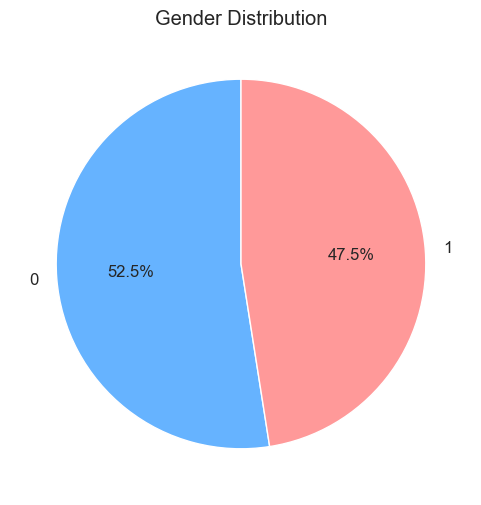

In [ ]:
plt.figure(figsize=(6,6))

train.Gender_Male.value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=["#66b3ff","#ff9999"]
)

plt.ylabel("")
plt.title("Gender Distribution")
plt.show()

C:\Users\tiger\AppData\Local\Temp\ipykernel_3444\2793232378.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train,x="Company Type_Service",palette="Set2")


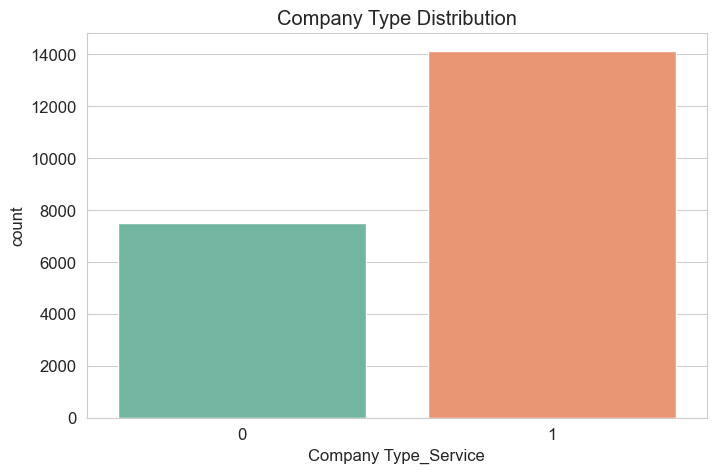

In [ ]:
sns.countplot(data=train,x="Company Type_Service",palette="Set2")

plt.title("Company Type Distribution")
plt.show()

C:\Users\tiger\AppData\Local\Temp\ipykernel_3444\282107589.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train,x="WFH Setup Available_Yes",palette="Set1")


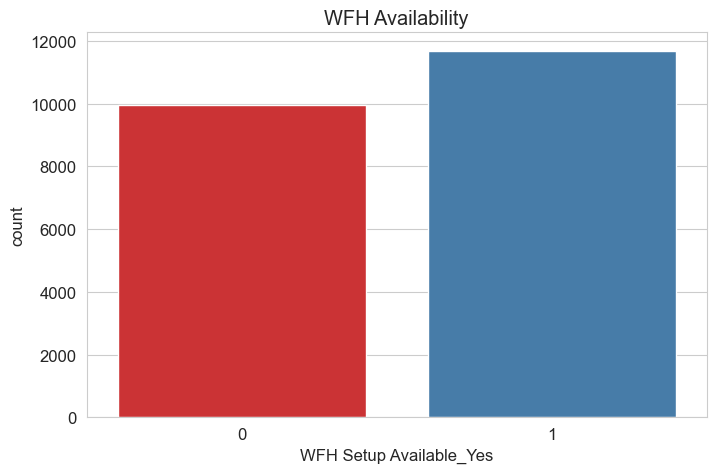

In [ ]:
sns.countplot(data=train,x="WFH Setup Available_Yes",palette="Set1")

plt.title("WFH Availability")
plt.show()

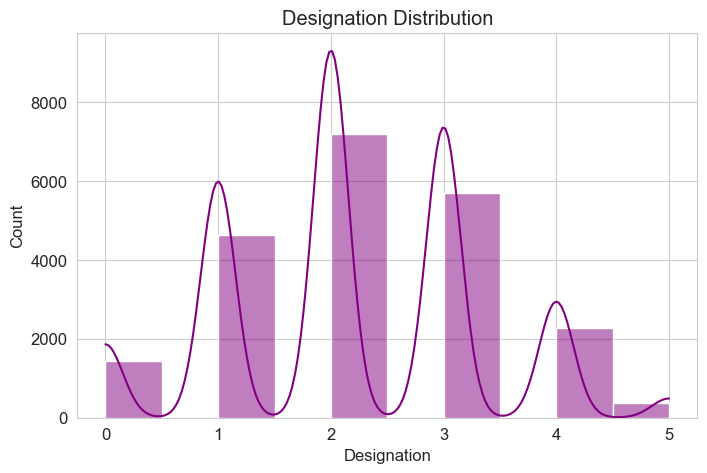

In [ ]:
sns.histplot(
    train["Designation"],
    bins=10,
    kde=True,
    color="purple"
)

plt.title("Designation Distribution")
plt.show()

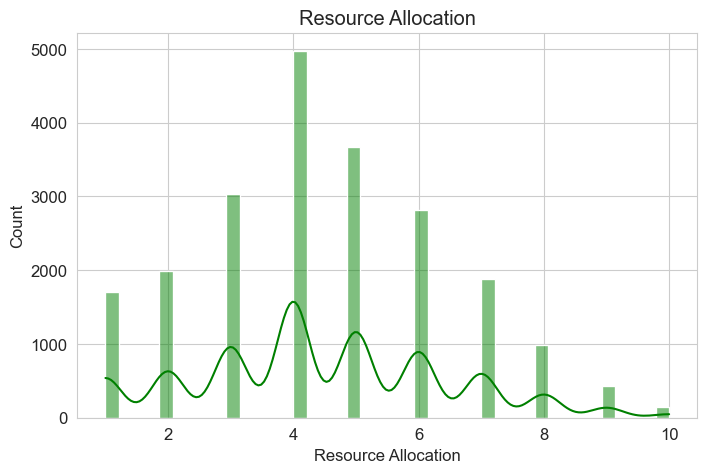

In [ ]:
sns.histplot(
    train["Resource Allocation"],
    kde=True,
    color="green"
)

plt.title("Resource Allocation")
plt.show()

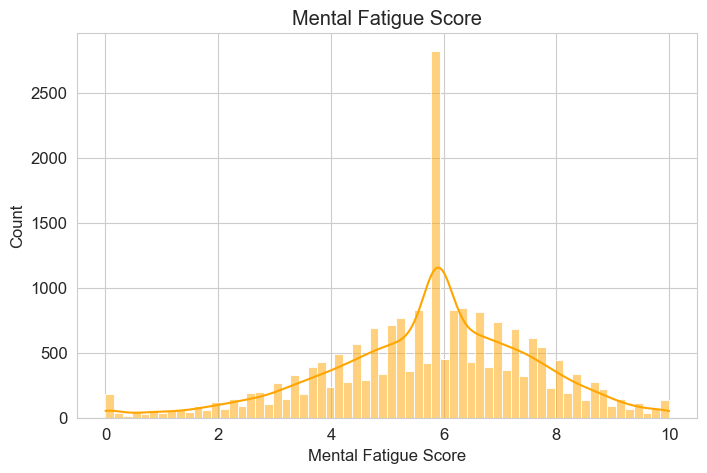

In [ ]:
sns.histplot(
    train["Mental Fatigue Score"],
    kde=True,
    color="orange"
)

plt.title("Mental Fatigue Score")
plt.show()

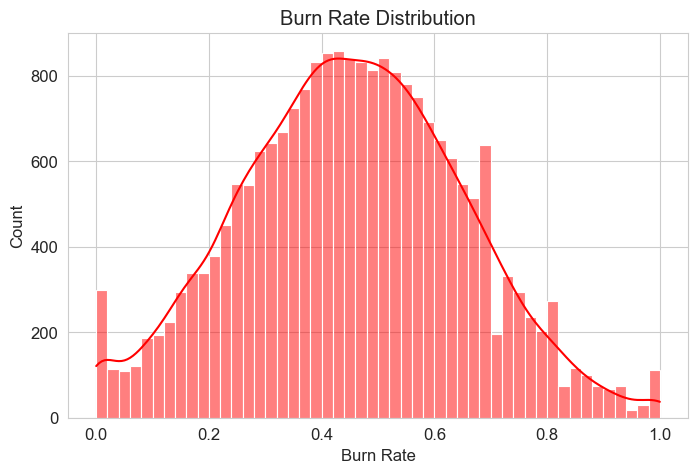

In [ ]:
sns.histplot(
    train["Burn Rate"],
    kde=True,
    color="red"
)

plt.title("Burn Rate Distribution")
plt.show()

C:\Users\tiger\AppData\Local\Temp\ipykernel_3444\534178121.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


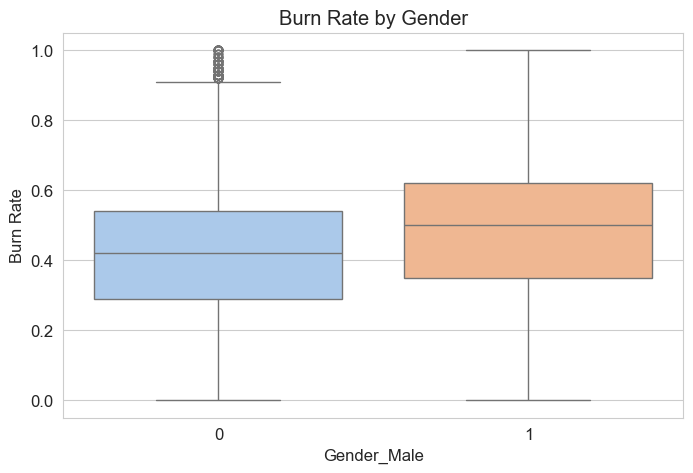

In [ ]:
sns.boxplot(
    data=train,
    x="Gender_Male",
    y="Burn Rate",
    palette="pastel"
)

plt.title("Burn Rate by Gender")
plt.show()

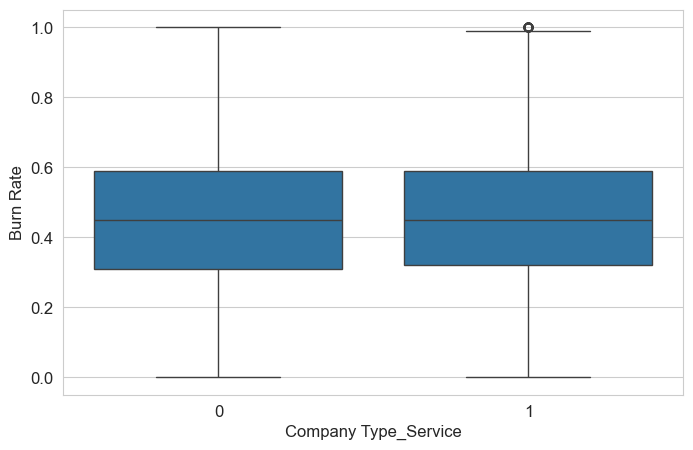

In [ ]:
sns.boxplot(
    data=train,
    x="Company Type_Service",
    y="Burn Rate"
)

plt.show()

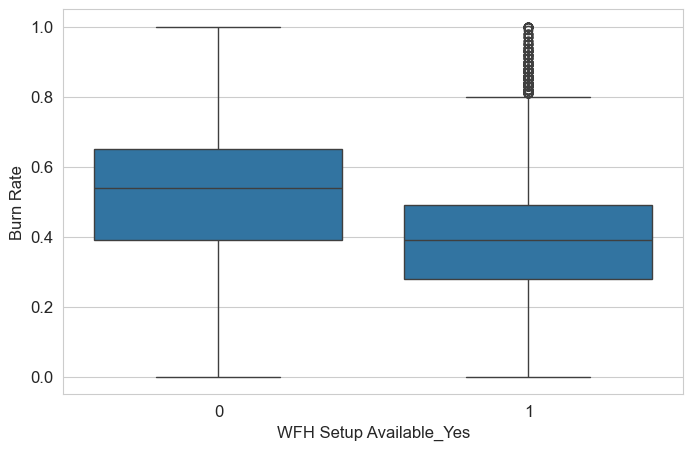

In [ ]:
sns.boxplot(
    data=train,
    x="WFH Setup Available_Yes",
    y="Burn Rate"
)

plt.show()

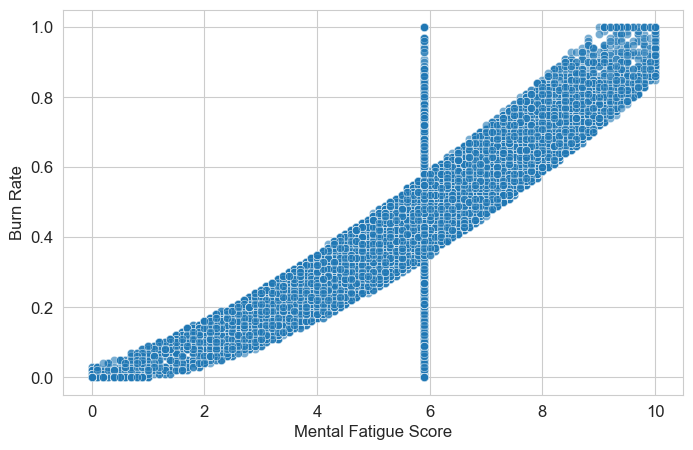

In [ ]:
sns.scatterplot(
    data=train,
    x="Mental Fatigue Score",
    y="Burn Rate",
    alpha=0.6
)

plt.show()

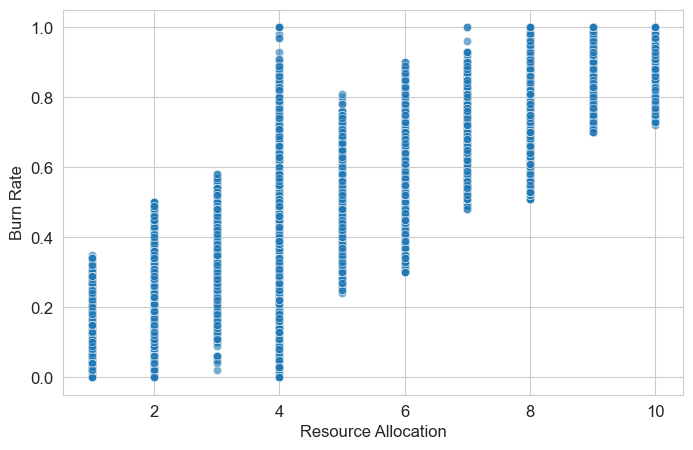

In [ ]:
sns.scatterplot(
    data=train,
    x="Resource Allocation",
    y="Burn Rate",
    alpha=0.6
)

plt.show()

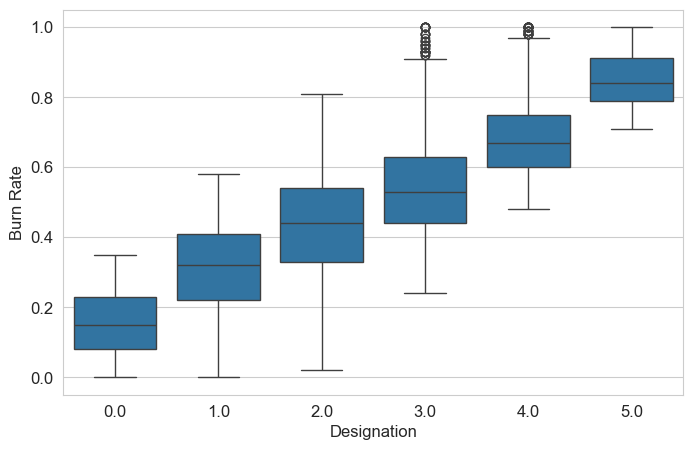

In [ ]:
sns.boxplot(
    data=train,
    x="Designation",
    y="Burn Rate"
)

plt.show()

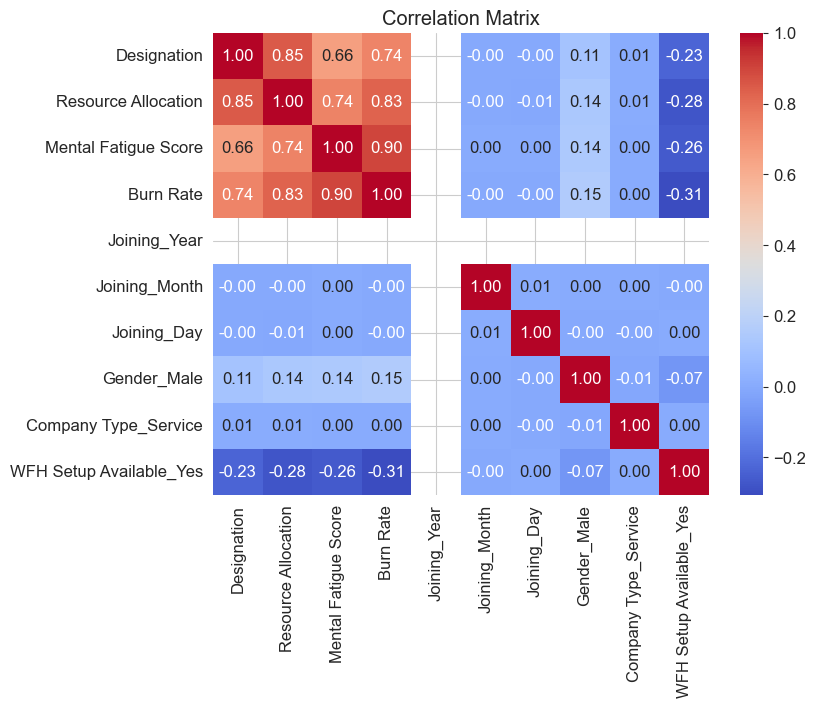

In [ ]:
plt.figure(figsize=(8,6))

corr = train.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

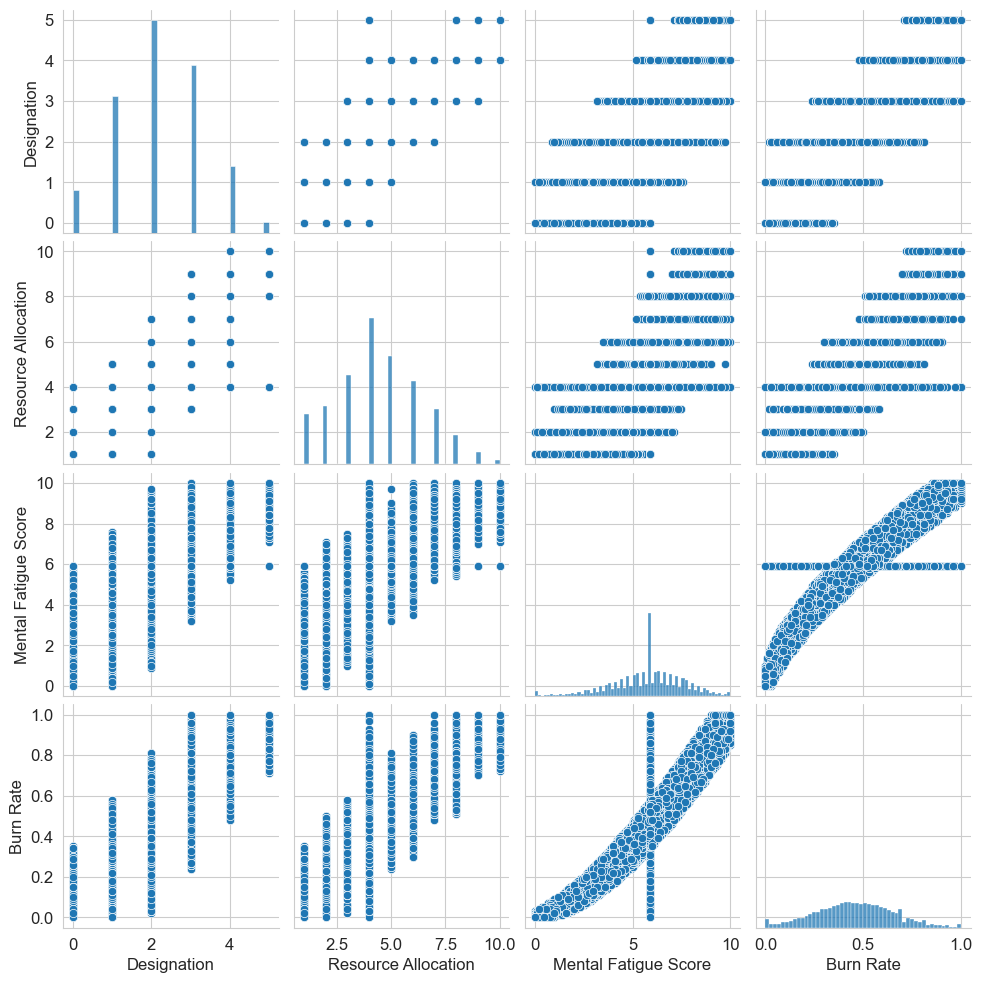

In [ ]:
sns.pairplot(
    train[
        [
            "Designation",
            "Resource Allocation",
            "Mental Fatigue Score",
            "Burn Rate"
        ]
    ]
)

# 8. Data Preprocessing

In [ ]:
X_train = train.drop("Burn Rate", axis=1)
y_train = train["Burn Rate"]

In [ ]:
X_train

,Designation,Resource Allocation,Mental Fatigue Score,Joining_Year,Joining_Month,Joining_Day,Gender_Male,Company Type_Service,WFH Setup Available_Yes
0,2.0,3.0,3.8,2008,9,30,0,1,0
1,1.0,2.0,5.0,2008,11,30,1,1,1
2,2.0,4.0,5.8,2008,3,10,0,0,1
3,1.0,1.0,2.6,2008,11,3,1,1,1
4,3.0,7.0,6.9,2008,7,24,0,1,0
...,...,...,...,...,...,...,...,...,...
22745,1.0,3.0,5.9,2008,12,30,0,1,0
22746,3.0,6.0,6.7,2008,1,19,0,0,1
22747,3.0,7.0,5.9,2008,11,5,1,1,1
22748,2.0,5.0,5.9,2008,1,10,0,1,0


In [ ]:
y_train

0        0.16
1        0.36
2        0.49
3        0.20
4        0.52
         ... 
22745    0.41
22746    0.59
22747    0.72
22748    0.52
22749    0.61
Name: Burn Rate, Length: 21626, dtype: float64

In [ ]:
X_test = test.copy()

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)

(21626, 9)
(21626,)
(12250, 9)


In [ ]:
numerical_features = X_train.select_dtypes(include=["number"]).columns.tolist()
numerical_features

['Designation',
 'Resource Allocation',
 'Mental Fatigue Score',
 'Joining_Year',
 'Joining_Month',
 'Joining_Day',
 'Gender_Male',
 'Company Type_Service',
 'WFH Setup Available_Yes']

In [ ]:
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

categorical_features

[]

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
    ]
)

# Bagging

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

In [ ]:
bagging_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", BaggingRegressor(
        estimator=DecisionTreeRegressor(
            max_depth=15,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42
        ),
        n_estimators=500,
        max_samples=0.9,
        max_features=0.9,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ))
])

In [ ]:
bagging_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Designation',
                                                   'Resource Allocation',
                                                   'Mental Fatigue Score',
                                                   'Joining_Year',
                                                   'Joining_Month',
                                                   'Joining_Day', 'Gender_Male',
                                                   'Company Type_Service',
                                                   'WFH Setup '
                                                   'Available_Yes'])])),
                ('model',
                 BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=15,
                                                                  min_samples_leaf=2,
                                                                  min_samples_split=5,
                                                                  random_state=42),
                                  max_features=0.9, max_samples=0.9,
                                  n_estimators=500, n_jobs=-1,
                                  random_state=42))])

In [ ]:
y_pred = bagging_pipeline.predict(X_valid)

In [ ]:
print(f"R² Score : {r2_score(y_valid, y_pred):.4f}")
print(f"MAE      : {mean_absolute_error(y_valid, y_pred):.4f}")
print(f"MSE      : {mean_squared_error(y_valid, y_pred):.4f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_valid, y_pred)):.4f}")

R² Score : 0.9021
MAE      : 0.0475
MSE      : 0.0037
RMSE     : 0.0611


# Adaboost

In [ ]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", AdaBoostRegressor(
        estimator=DecisionTreeRegressor(
            max_depth=4,
            random_state=42
        ),
        n_estimators=300,
        learning_rate=0.05,
        loss="square",
        random_state=42
    ))
])

In [ ]:
bagging_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Designation',
                                                   'Resource Allocation',
                                                   'Mental Fatigue Score',
                                                   'Joining_Year',
                                                   'Joining_Month',
                                                   'Joining_Day', 'Gender_Male',
                                                   'Company Type_Service',
                                                   'WFH Setup '
                                                   'Available_Yes'])])),
                ('model',
                 BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=15,
                                                                  min_samples_leaf=2,
                                                                  min_samples_split=5,
                                                                  random_state=42),
                                  max_features=0.9, max_samples=0.9,
                                  n_estimators=500, n_jobs=-1,
                                  random_state=42))])

In [ ]:
y_pred = bagging_pipeline.predict(X_valid)

In [ ]:
print(f"R² Score : {r2_score(y_valid, y_pred):.4f}")
print(f"MAE      : {mean_absolute_error(y_valid, y_pred):.4f}")
print(f"MSE      : {mean_squared_error(y_valid, y_pred):.4f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_valid, y_pred)):.4f}")

R² Score : 0.9021
MAE      : 0.0475
MSE      : 0.0037
RMSE     : 0.0611


# Gbooost

In [ ]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        loss="squared_error",
        learning_rate=0.03,
        n_estimators=800,
        subsample=0.9,
        max_depth=4,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=None,
        random_state=42
    ))
])

In [ ]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Designation',
                                                   'Resource Allocation',
                                                   'Mental Fatigue Score',
                                                   'Joining_Year',
                                                   'Joining_Month',
                                                   'Joining_Day', 'Gender_Male',
                                                   'Company Type_Service',
                                                   'WFH Setup '
                                                   'Available_Yes'])])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.03, max_depth=4,
                                           n_estimators=800, random_state=42,
                                           subsample=0.9))])

In [ ]:
y_pred = pipeline.predict(X_valid)

In [ ]:
print(f"R² Score : {r2_score(y_valid, y_pred):.4f}")
print(f"MAE      : {mean_absolute_error(y_valid, y_pred):.4f}")
print(f"MSE      : {mean_squared_error(y_valid, y_pred):.4f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_valid, y_pred)):.4f}")

R² Score : 0.9047
MAE      : 0.0474
MSE      : 0.0036
RMSE     : 0.0602


# XGboost

In [ ]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

In [ ]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Designation',
                                                   'Resource Allocation',
                                                   'Mental Fatigue Score',
                                                   'Joining_Year',
                                                   'Joining_Month',
                                                   'Joining_Day', 'Gender_Male',
                                                   'Company Type_Service',
                                                   'WFH Setup '
                                                   'Available_Yes'])])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, cols...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [ ]:
y_pred = pipeline.predict(X_valid)

In [ ]:
print(f"R² Score : {r2_score(y_valid, y_pred):.4f}")
print(f"MAE      : {mean_absolute_error(y_valid, y_pred):.4f}")
print(f"MSE      : {mean_squared_error(y_valid, y_pred):.4f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_valid, y_pred)):.4f}")

R² Score : 0.9045
MAE      : 0.0473
MSE      : 0.0036
RMSE     : 0.0603


In [ ]:
X = train.drop("Burn Rate", axis=1)
y = train["Burn Rate"]

pipeline.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Designation',
                                                   'Resource Allocation',
                                                   'Mental Fatigue Score',
                                                   'Joining_Year',
                                                   'Joining_Month',
                                                   'Joining_Day', 'Gender_Male',
                                                   'Company Type_Service',
                                                   'WFH Setup '
                                                   'Available_Yes'])])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, cols...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [ ]:
predictions = pipeline.predict(test)

In [ ]:
submission = pd.DataFrame({
    "Burn Rate": predictions
})

submission.to_csv("submission.csv", index=False)

In [ ]:
df=pd.read_csv("submission.csv")

In [ ]:
df.head()

,Burn Rate
0,0.615154
1,0.359521
2,0.366023
3,0.396002
4,0.527043


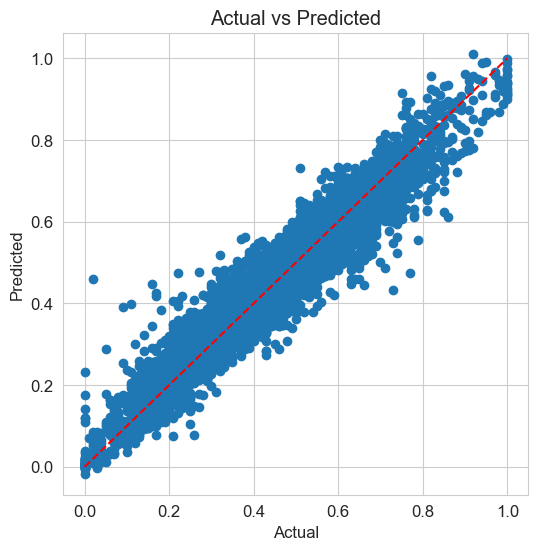

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_valid, y_pred)
plt.plot([y_valid.min(), y_valid.max()],
         [y_valid.min(), y_valid.max()],
         'r--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

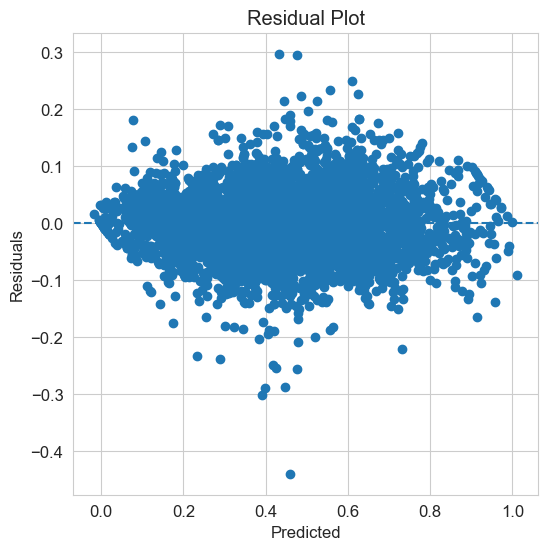

In [ ]:
residuals = y_valid - y_pred

plt.figure(figsize=(6,6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()